> Ensure `tool.py` is on the Python path.

# 활성화 함수 (Activation Functions)

활성화 함수는 신경망에 **비선형성**을 부여합니다. 이 없으면 아무리 층을 쌓아도 결국 단일 선형 변환과 동일합니다.  
이 노트북에서는 주요 활성화 함수의 특성, 죽은 뉴런 문제, 그래디언트 흐름을 실험으로 비교합니다.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from tool import (
    seed_all,
    device,
    load_mnist_small,
    train_classifier,
    accuracy,
    compare_table,
    plot_activation_overview,
    plot_dead_neuron_bars,
    plot_activation_training_summary,
    plot_grad_norm_per_activation,
)
seed_all(42)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

## 1. 활성화 함수와 도함수 시각화

| 함수 | 수식 | 범위 | 특징 |
|------|------|------|---------|
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0,1) | 기울기 소실 |
| Tanh | $\tanh(x)$ | (-1,1) | 0 중심, 기울기 소실 |
| ReLU | $\max(0,x)$ | [0,∞) | 빠름, 죽은 뉴런 |
| GELU | $x \cdot \Phi(x)$ | (-∞,∞) | 부드러움, Transformer |
| Swish | $x \cdot \sigma(x)$ | (-∞,∞) | GELU와 유사 |

In [2]:
x_np = np.linspace(-4, 4, 400)
x_t  = torch.tensor(x_np, dtype=torch.float32, requires_grad=True)

act_fns = {
    'Sigmoid': torch.sigmoid,
    'Tanh':    torch.tanh,
    'ReLU':    F.relu,
    'GELU':    F.gelu,
    'Swish':   lambda x: x * torch.sigmoid(x),
}

act_vals  = {}
grad_vals = {}
for name, fn in act_fns.items():
    x_t2 = torch.tensor(x_np, dtype=torch.float32, requires_grad=True)
    y = fn(x_t2)
    y.sum().backward()
    act_vals[name]  = y.detach().numpy()
    grad_vals[name] = x_t2.grad.numpy()

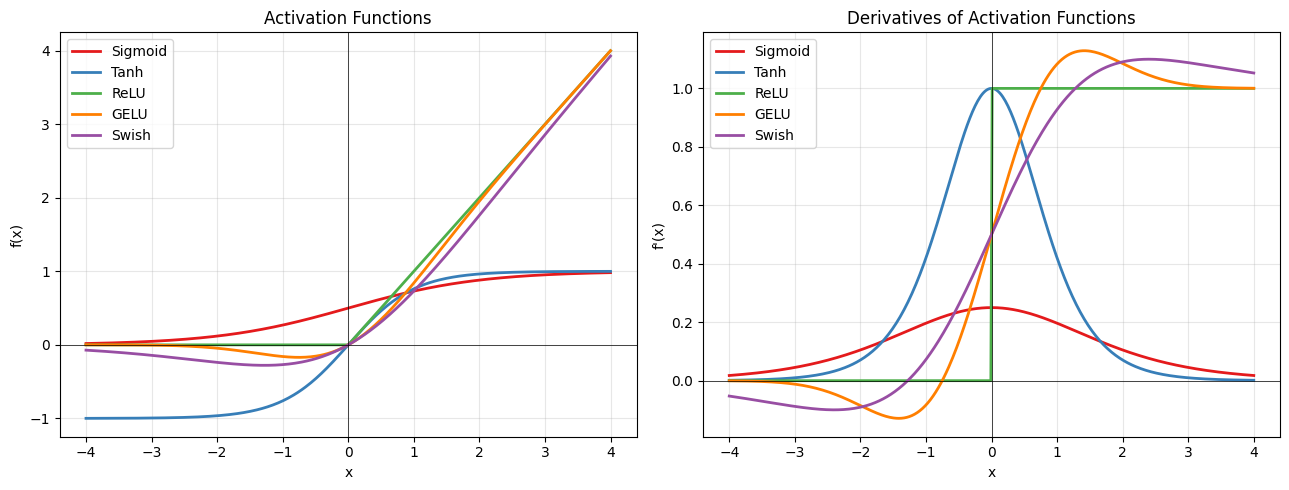

In [3]:
plot_activation_overview(act_vals, grad_vals, x_np)

## 2. 죽은 뉴런(Dying ReLU) 데모

ReLU 네트워크를 **큰 음수 편향(bias)**으로 초기화하면, 뉴런의 출력이 항상 0이 되어 가중치가 업데이트되지 않습니다.  
각 레이어별로 학습 후 **죽은 뉴런 수**를 카운트합니다.

In [ ]:
class DeadNeuronMLP(nn.Module):
    def __init__(self, bias_init=-5.0):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(784, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
            nn.Linear(128, 128),
        ])
        self.out = nn.Linear(128, 10)
        # Initialize biases with large negative values to cause dying ReLU
        for layer in self.layers:
            nn.init.xavier_uniform_(layer.weight)
            nn.init.constant_(layer.bias, bias_init)

    def forward(self, x):
        for layer in self.layers:
            x = F.relu(layer(x))
        return self.out(x)

In [5]:
Xtr, ytr, Xte, yte = load_mnist_small(n_train=2000, n_test=500, flatten=True)
print(f"Train: {Xtr.shape}, Test: {Xte.shape}")

Train: torch.Size([2000, 784]), Test: torch.Size([500, 784])


In [6]:
seed_all(42)
model_dead = DeadNeuronMLP(bias_init=-5.0)
hist_dead  = train_classifier(model_dead, Xtr, ytr, epochs=10, lr=1e-3, verbose=False)

In [7]:
def count_dead_neurons(model, X, threshold=1e-6):
    """Count fraction of neurons with near-zero activation across all samples."""
    dead_counts = []
    model.eval()
    dev = next(model.parameters()).device
    with torch.no_grad():
        x = X.to(dev)
        for layer in model.layers:
            x = F.relu(layer(x))
            # A neuron is 'dead' if it outputs 0 for ALL samples
            dead = (x.abs().max(dim=0).values < threshold).sum().item()
            dead_counts.append(dead)
    return dead_counts

dead_counts = count_dead_neurons(model_dead, Xtr)
for i, d in enumerate(dead_counts):
    print(f"Layer {i+1}: {d}/128 dead neurons ({100*d/128:.1f}%)")

Layer 1: 128/128 dead neurons (100.0%)
Layer 2: 128/128 dead neurons (100.0%)
Layer 3: 128/128 dead neurons (100.0%)
Layer 4: 128/128 dead neurons (100.0%)


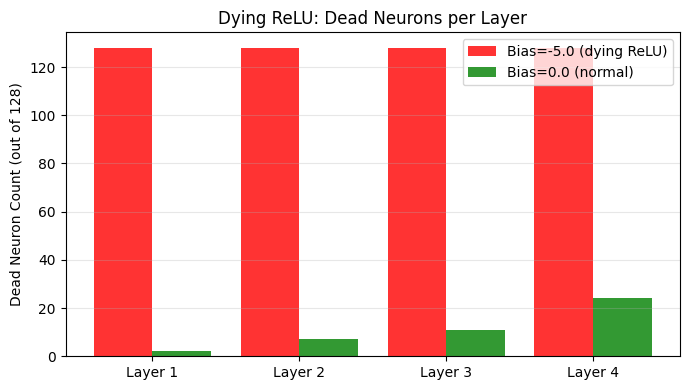

In [8]:
# Compare with normal initialization
seed_all(42)
model_normal = DeadNeuronMLP(bias_init=0.0)
train_classifier(model_normal, Xtr, ytr, epochs=10, lr=1e-3, verbose=False)
normal_counts = count_dead_neurons(model_normal, Xtr)

plot_dead_neuron_bars(dead_counts, normal_counts)

## 3. MNIST에서 활성화 함수별 그래디언트 추적

동일한 4-레이어 MLP를 **ReLU / Sigmoid / Tanh / GELU / Swish**로 학습하면서,  
각 레이어의 **그래디언트 노름(gradient norm)**을 에포크마다 기록합니다.

기울기 소실(Vanishing Gradient) 문제가 어떤 함수에서 더 심한지 확인합니다.

In [ ]:
def make_mlp(act_fn):
    """4-layer MLP with given activation function."""
    return nn.Sequential(
        nn.Linear(784, 256), act_fn(),
        nn.Linear(256, 128), act_fn(),
        nn.Linear(128, 64),  act_fn(),
        nn.Linear(64,  32),  act_fn(),
        nn.Linear(32,  10),
    )

act_configs = {
    'ReLU':    nn.ReLU,
    'Sigmoid': nn.Sigmoid,
    'Tanh':    nn.Tanh,
    'GELU':    nn.GELU,
    'Swish':   nn.SiLU,
}

In [ ]:
def train_and_track_grads(model, X, y, epochs=20, lr=1e-3, batch_size=64):
    """Train model, return loss history + per-layer grad norm history."""
    dev = device()
    model = model.to(dev)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    ds = TensorDataset(X, y)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    # Identify linear layers (indices where weight has grad)
    linear_layers = [m for m in model.modules() if isinstance(m, nn.Linear)]

    loss_hist = []
    grad_hist = {i: [] for i in range(len(linear_layers))}

    for ep in range(epochs):
        model.train()
        ep_loss = 0.0
        for xb, yb in dl:
            xb, yb = xb.to(dev), yb.to(dev)
            opt.zero_grad()
            out = model(xb)
            loss = loss_fn(out, yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item() * xb.size(0)
        ep_loss /= len(ds)
        loss_hist.append(ep_loss)

        # Record gradient norms after epoch
        for i, layer in enumerate(linear_layers):
            if layer.weight.grad is not None:
                grad_hist[i].append(layer.weight.grad.norm().item())
            else:
                grad_hist[i].append(0.0)
    return loss_hist, grad_hist, linear_layers

In [11]:
EPOCHS = 20
all_results = {}

for act_name, act_cls in act_configs.items():
    seed_all(42)
    model = make_mlp(act_cls)
    loss_h, grad_h, _ = train_and_track_grads(model, Xtr, ytr, epochs=EPOCHS, lr=1e-3)
    acc = accuracy(model, Xte, yte)
    all_results[act_name] = {
        'loss_hist': loss_h,
        'grad_hist': grad_h,
        'model':     model,
        'accuracy':  acc,
    }
    print(f"{act_name:8s} | final_loss={loss_h[-1]:.4f} | test_acc={acc:.4f}")

ReLU     | final_loss=0.0251 | test_acc=0.9220
Sigmoid  | final_loss=0.7841 | test_acc=0.7100
Tanh     | final_loss=0.0222 | test_acc=0.9200
GELU     | final_loss=0.0179 | test_acc=0.9220
Swish    | final_loss=0.0260 | test_acc=0.9200


## 4. 최종 비교: 정확도, 수렴 속도, 죽은 뉴런, 레이어별 그래디언트 노름

In [ ]:
# Final accuracy comparison
comparison = {}
for act_name, res in all_results.items():
    # Steps to reach 50% train accuracy proxy via loss < 1.0
    losses = res['loss_hist']
    below = next((i for i, l in enumerate(losses) if l < 1.0), EPOCHS)
    comparison[act_name] = {
        'test_acc':       round(res['accuracy'], 4),
        'final_loss':     round(losses[-1], 4),
        'epoch_loss<1.0': below,
    }
compare_table(comparison)

model         test_acc      final_loss    epoch_loss<1.0
--------------------------------------------------------
ReLU          0.922         0.0251        2             
Sigmoid       0.71          0.7841        15            
Tanh          0.92          0.0222        2             
GELU          0.922         0.0179        1             
Swish         0.92          0.026         1             


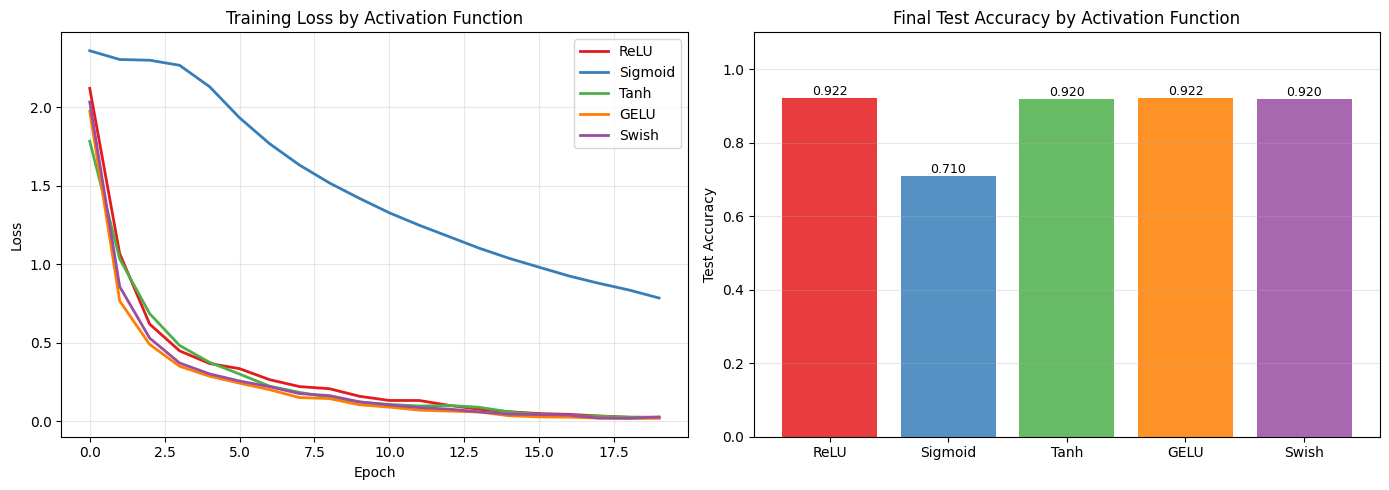

In [13]:
plot_activation_training_summary(all_results)

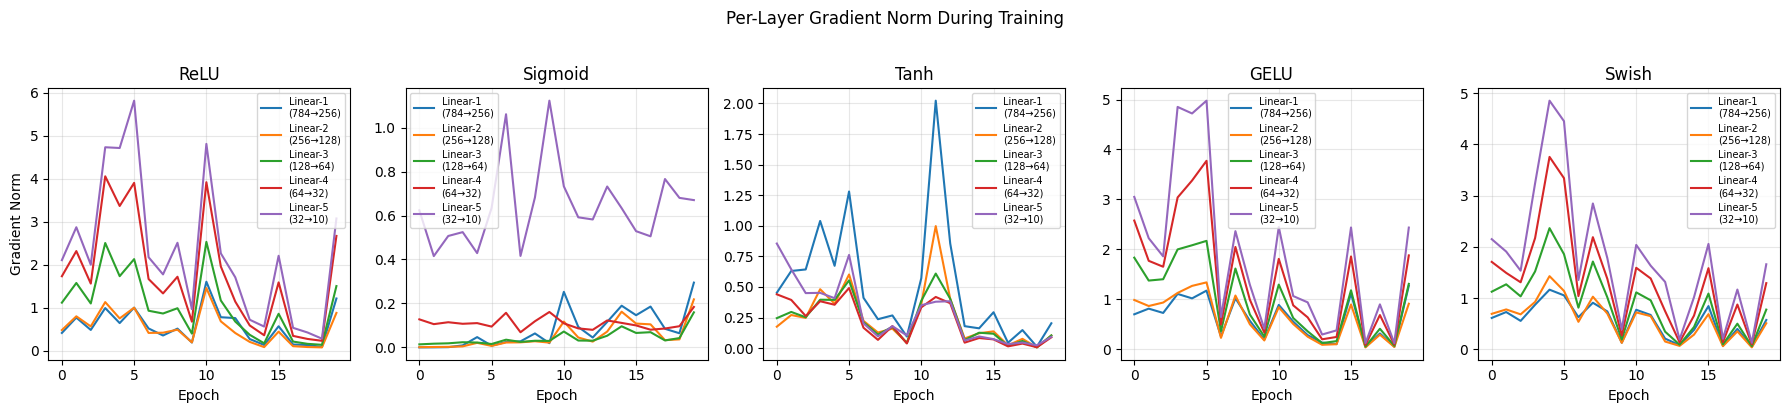

Note: Sigmoid/Tanh show gradient vanishing (lower norms in early layers).


In [14]:
# Per-layer gradient norm across training (first layer = deepest, last = closest to loss)
layer_names = ['Linear-1\n(784→256)', 'Linear-2\n(256→128)',
               'Linear-3\n(128→64)',  'Linear-4\n(64→32)', 'Linear-5\n(32→10)']
plot_grad_norm_per_activation(all_results, layer_names)
print("Note: Sigmoid/Tanh show gradient vanishing (lower norms in early layers).")

In [ ]:
# Dead neuron counts for ReLU model
relu_model = all_results['ReLU']['model']
# Get linear layers from sequential
relu_linears = [m for m in relu_model.modules() if isinstance(m, nn.Linear)]

dead_per_layer = []
relu_model.eval()
dev = next(relu_model.parameters()).device
with torch.no_grad():
    x = Xtr.to(dev)
    for i, (layer, act) in enumerate(zip(relu_linears[:-1],
                                         [m for m in relu_model if isinstance(m, nn.ReLU)])):
        x = F.relu(layer(x))
        dead = (x.abs().max(dim=0).values < 1e-6).sum().item()
        dead_per_layer.append(dead)

print("Dead neurons in ReLU model after 20 epochs of training (normal init):")
for i, d in enumerate(dead_per_layer):
    total = [256, 128, 64, 32][i]
    print(f"  Layer {i+1}: {d}/{total} dead ({100*d/total:.1f}%)")

Dead neurons in ReLU model after 20 epochs of training (normal init):
  Layer 1: 19/256 dead (7.4%)
  Layer 2: 34/128 dead (26.6%)
  Layer 3: 17/64 dead (26.6%)
  Layer 4: 7/32 dead (21.9%)
